# 08 — Coupled Multiphysics & Noise/Decoherence Analysis

This notebook brings together the two new Phase 2 modules:

1. **Coupled Physics** — Acoustic/EM/Thermal interaction via slowly-varying envelope approximation (SVEA)
2. **Noise & Decoherence** — Realistic noise budget (thermal, shot, 1/f, phase diffusion, ADC) and mode lifetime

### Key Questions
- How much energy transfers between acoustic and EM modes?
- Does thermal feedback destabilize stored modes?
- What is the dominant noise source limiting mode lifetime?
- How many reliable modes survive under realistic conditions?
- Does the noise model support the paper's storage density claims?

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Imports OK')

Imports OK


## Part 1: Coupled Multiphysics Simulation

In [2]:
from simulations.coupled_physics import (
    run_coupled_simulation, CouplingParams,
    coupled_summary, acoustic_eigenfrequencies, em_eigenfrequencies,
    coupling_strength_scan, thermal_feedback_test,
)

# Default simulation: 5 acoustic modes, 3 EM modes
params = CouplingParams(
    n_acoustic=5,
    n_em=3,
    kappa_ae=1e-3,
    chi_nonlinear=1e-6,
    eta_acoustic=50,
    eta_em=100,
)

# Excite modes 1 and 3 (selective pattern storage)
initial = np.zeros(5, dtype=complex)
initial[0] = 1.0   # mode 1
initial[2] = 0.7j  # mode 3 (phase-shifted)

result = run_coupled_simulation(
    params=params,
    t_max=5e-4,  # 500 µs
    n_points=2000,
    initial_acoustic=initial,
)

print(coupled_summary(result))

  COUPLED MULTIPHYSICS SIMULATION SUMMARY
  Acoustic modes:  5
  EM modes:        3
  κ_ae coupling:   1.0e-03
  χ_nonlinear:     1.0e-06
  Duration:        500.0 µs
------------------------------------------------------------
  ENERGY
    Initial total:       1.4900e+00
    Final total:         1.4173e+00
    Energy retained:     95.1%
    Max EM energy:       8.0273e-16
    Peak transfer rate:  5.8474e-11 /s
------------------------------------------------------------
  COHERENCE
    Coherence time (1/e): 500.0 µs
    Mode crosstalk (max): 1.0000
------------------------------------------------------------
  THERMAL
    Initial ΔT:   0.00 K
    Final ΔT:     0.0000 K
    Max ΔT:       0.0000 K


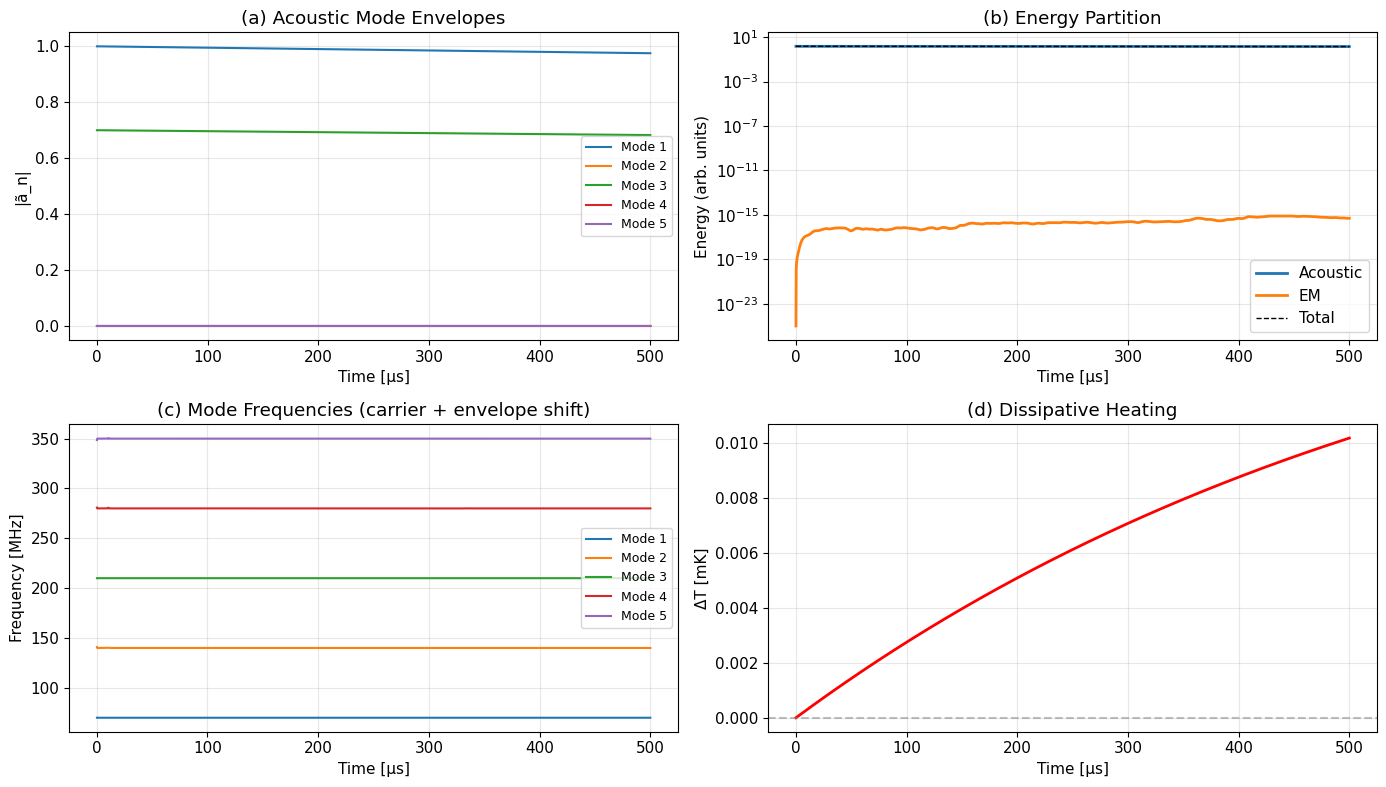

Figure saved.


In [3]:
# Plot acoustic mode amplitudes over time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) Mode amplitudes
ax = axes[0, 0]
t_us = result.times * 1e6
for n in range(params.n_acoustic):
    ax.plot(t_us, np.abs(result.acoustic_amplitudes[:, n]),
            label=f'Mode {n+1}', linewidth=1.5)
ax.set_xlabel('Time [µs]')
ax.set_ylabel('|ã_n|')
ax.set_title('(a) Acoustic Mode Envelopes')
ax.legend(fontsize=9)

# (b) Energy partition
ax = axes[0, 1]
a_total = np.sum(result.acoustic_energies, axis=1)
em_total = np.sum(result.em_energies, axis=1)
ax.semilogy(t_us, a_total, label='Acoustic', linewidth=2)
ax.semilogy(t_us, np.maximum(em_total, 1e-25), label='EM', linewidth=2)
ax.semilogy(t_us, result.total_energy, 'k--', label='Total', linewidth=1)
ax.set_xlabel('Time [µs]')
ax.set_ylabel('Energy (arb. units)')
ax.set_title('(b) Energy Partition')
ax.legend()

# (c) Frequency tracking
ax = axes[1, 0]
for n in range(params.n_acoustic):
    f_mhz = result.acoustic_freqs[:, n] / 1e6
    ax.plot(t_us[1:], f_mhz[1:], label=f'Mode {n+1}', linewidth=1.5)
ax.set_xlabel('Time [µs]')
ax.set_ylabel('Frequency [MHz]')
ax.set_title('(c) Mode Frequencies (carrier + envelope shift)')
ax.legend(fontsize=9)

# (d) Temperature perturbation
ax = axes[1, 1]
ax.plot(t_us, result.temperature * 1e3, 'r-', linewidth=2)
ax.set_xlabel('Time [µs]')
ax.set_ylabel('ΔT [mK]')
ax.set_title('(d) Dissipative Heating')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../analysis/figures/coupled_physics_overview.png', dpi=150)
plt.show()
print('Figure saved.')

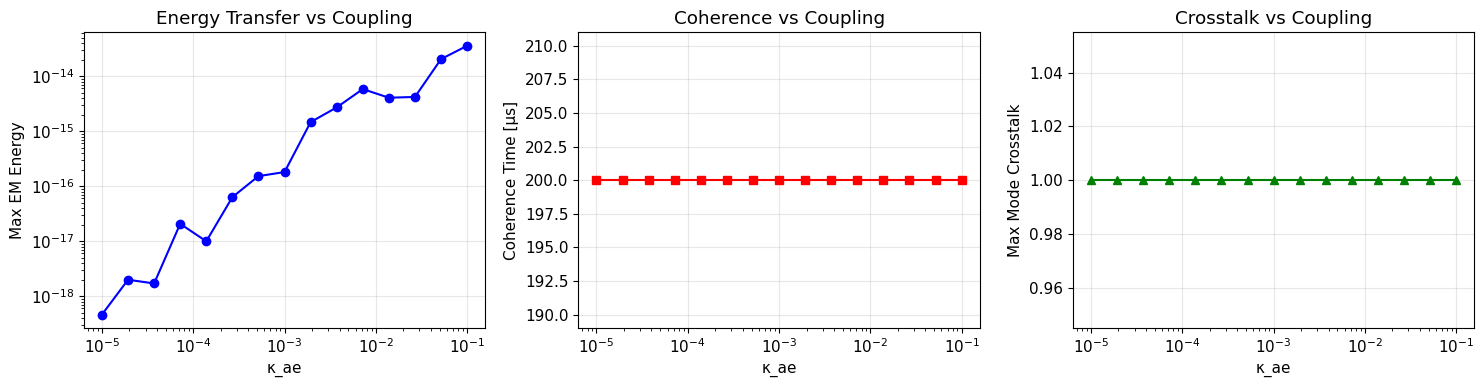

Coupling scan complete.


In [4]:
# Coupling strength scan: how does κ_ae affect energy transfer?
kappas = np.logspace(-5, -1, 15)
scan = coupling_strength_scan(kappa_values=kappas, t_max=2e-4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].loglog(scan['kappa'], scan['max_em_energy'], 'bo-')
axes[0].set_xlabel('κ_ae')
axes[0].set_ylabel('Max EM Energy')
axes[0].set_title('Energy Transfer vs Coupling')

axes[1].semilogx(scan['kappa'], scan['coherence_time'] * 1e6, 'rs-')
axes[1].set_xlabel('κ_ae')
axes[1].set_ylabel('Coherence Time [µs]')
axes[1].set_title('Coherence vs Coupling')

axes[2].semilogx(scan['kappa'], scan['max_crosstalk'], 'g^-')
axes[2].set_xlabel('κ_ae')
axes[2].set_ylabel('Max Mode Crosstalk')
axes[2].set_title('Crosstalk vs Coupling')

plt.tight_layout()
plt.savefig('../analysis/figures/coupling_scan.png', dpi=150)
plt.show()
print('Coupling scan complete.')

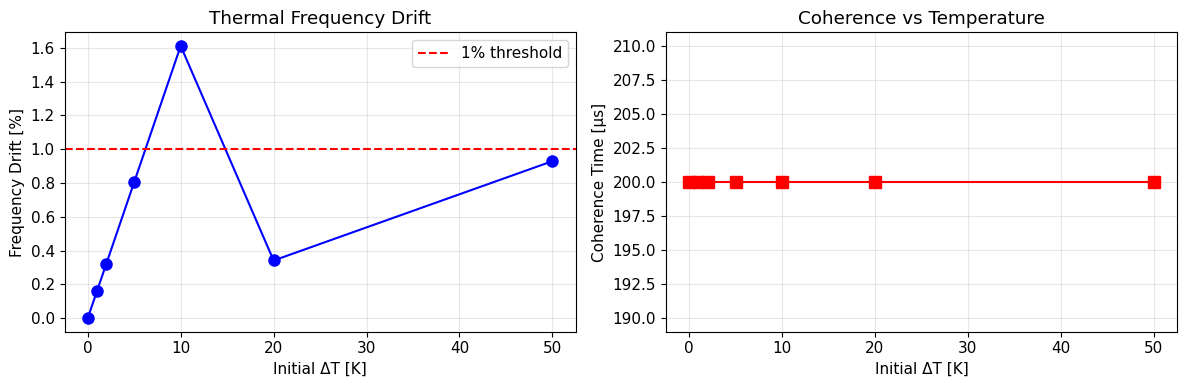


Max safe ΔT (drift < 1%): ±50 K
Paper assumes α = 0.0022/K → at ΔT=5K, drift = 0.6%


In [5]:
# Thermal feedback test
tf = thermal_feedback_test(
    delta_T_values=np.array([0, 1, 2, 5, 10, 20, 50]),
    t_max=2e-4,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tf['delta_T'], tf['freq_drift_pct'], 'bo-', markersize=8)
axes[0].axhline(y=1.0, color='r', linestyle='--', label='1% threshold')
axes[0].set_xlabel('Initial ΔT [K]')
axes[0].set_ylabel('Frequency Drift [%]')
axes[0].set_title('Thermal Frequency Drift')
axes[0].legend()

axes[1].plot(tf['delta_T'], tf['coherence_time'] * 1e6, 'rs-', markersize=8)
axes[1].set_xlabel('Initial ΔT [K]')
axes[1].set_ylabel('Coherence Time [µs]')
axes[1].set_title('Coherence vs Temperature')

plt.tight_layout()
plt.savefig('../analysis/figures/thermal_feedback.png', dpi=150)
plt.show()

# Summary
max_safe_dT = tf['delta_T'][tf['freq_drift_pct'] < 1.0][-1] if any(tf['freq_drift_pct'] < 1.0) else 0
print(f'\nMax safe ΔT (drift < 1%): ±{max_safe_dT:.0f} K')
print(f'Paper assumes α = 0.0022/K → at ΔT=5K, drift = {5*0.0022/2*100:.1f}%')

## Part 2: Noise & Decoherence Analysis

In [6]:
from simulations.noise_decoherence import (
    run_decoherence_analysis, NoiseParams,
    noise_budget_table, decoherence_summary,
    compute_noise_spectrum,
)

# Baseline analysis: default WCFOMA micro-cell
np_baseline = NoiseParams(
    T=300,
    Q=500,         # Paper default
    n_modes=10,
    n_adc_bits=10,
    A_signal=1.0,
    bandwidth=1e6,
)

print(noise_budget_table(np_baseline))

  NOISE BUDGET (at fundamental frequency 70.0 MHz)
  Source                             PSD   Fraction
-----------------------------------------------------------------
  Thermal (Johnson)            8.284e-12       0.0%
  Shot (optical)               1.000e-06      22.5%
  1/f (flicker)                1.429e-17       0.0%
  Phase diffusion              3.452e-06      77.5%
  ADC quantization             6.358e-13       0.0%
-----------------------------------------------------------------
  TOTAL                        4.452e-06     100.0%


In [7]:
# Full decoherence analysis
result_baseline = run_decoherence_analysis(
    params=np_baseline, t_max=1e-3, n_time_points=500
)
print(decoherence_summary(result_baseline))

  DECOHERENCE ANALYSIS SUMMARY
  Modes analyzed:       10
  Reliable modes:       0 (SNR > 10 dB)
  Max storage time:     0.0 µs
  Dominant noise:       phase_diffusion
  Effective density:    0.00 Tb/cm³
------------------------------------------------------------
  KILL CRITERIA
    SNR > 10 dB all modes:  FAIL ❌
    BER < 1% all modes:     FAIL ❌
    Lifetime > 1 µs:        FAIL ❌
------------------------------------------------------------
  PER-MODE SUMMARY
  Mode   Freq [MHz]   SNR [dB]   BER          τ [µs]    
  1      70.00        -6.5       3.18e-01     0.0       
  2      140.00       -6.5       3.18e-01     0.0       
  3      210.00       -6.5       3.18e-01     0.0       
  4      280.00       -6.5       3.18e-01     0.0       
  5      350.00       -6.5       3.18e-01     0.0       
  6      420.00       -6.5       3.18e-01     0.0       
  7      490.00       -6.5       3.18e-01     0.0       
  8      560.00       -6.5       3.18e-01     0.0       
  9      630.00     

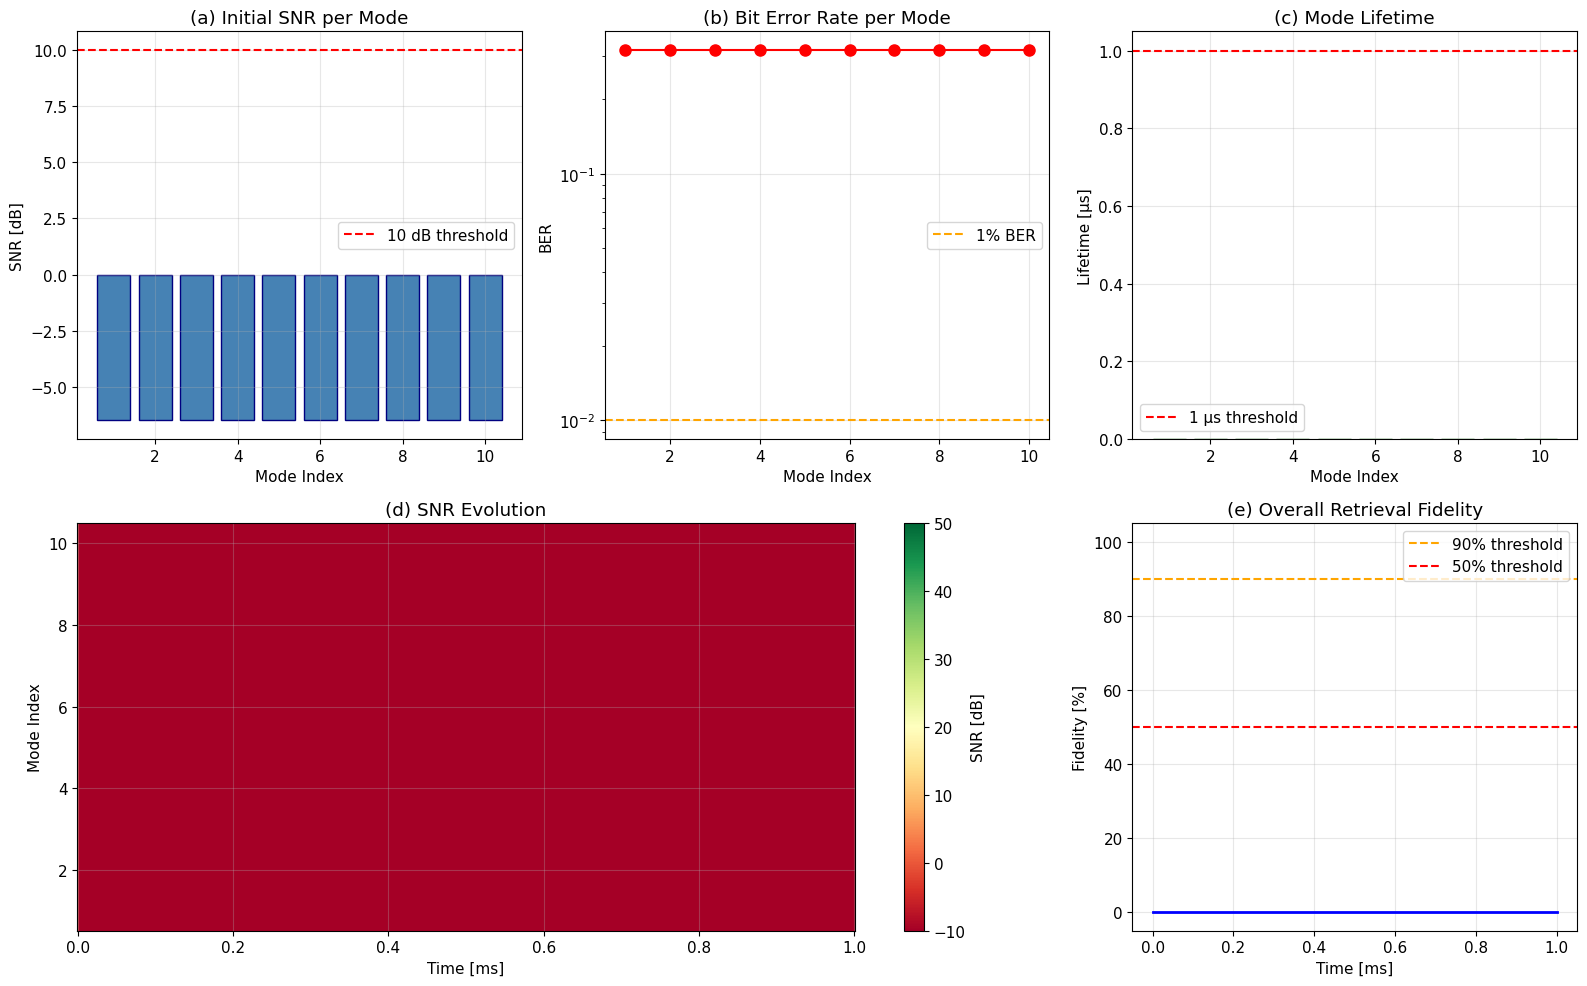

Decoherence baseline analysis complete.


In [8]:
# Visualize decoherence
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig)

# (a) SNR per mode
ax = fig.add_subplot(gs[0, 0])
ax.bar(result_baseline.mode_indices, result_baseline.snr_per_mode,
       color='steelblue', edgecolor='navy')
ax.axhline(y=10, color='r', linestyle='--', label='10 dB threshold')
ax.set_xlabel('Mode Index')
ax.set_ylabel('SNR [dB]')
ax.set_title('(a) Initial SNR per Mode')
ax.legend()

# (b) BER per mode
ax = fig.add_subplot(gs[0, 1])
ax.semilogy(result_baseline.mode_indices, result_baseline.ber_per_mode,
            'ro-', markersize=8)
ax.axhline(y=0.01, color='orange', linestyle='--', label='1% BER')
ax.set_xlabel('Mode Index')
ax.set_ylabel('BER')
ax.set_title('(b) Bit Error Rate per Mode')
ax.legend()

# (c) Mode lifetime
ax = fig.add_subplot(gs[0, 2])
lifetimes_us = result_baseline.lifetime_per_mode * 1e6
ax.bar(result_baseline.mode_indices, lifetimes_us,
       color='forestgreen', edgecolor='darkgreen')
ax.axhline(y=1.0, color='r', linestyle='--', label='1 µs threshold')
ax.set_xlabel('Mode Index')
ax.set_ylabel('Lifetime [µs]')
ax.set_title('(c) Mode Lifetime')
ax.legend()

# (d) SNR vs time heatmap
ax = fig.add_subplot(gs[1, 0:2])
t_ms = result_baseline.times * 1e3
im = ax.pcolormesh(t_ms, result_baseline.mode_indices,
                    result_baseline.snr_vs_time.T,
                    cmap='RdYlGn', vmin=-10, vmax=50)
plt.colorbar(im, ax=ax, label='SNR [dB]')
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Mode Index')
ax.set_title('(d) SNR Evolution')

# (e) Fidelity vs time
ax = fig.add_subplot(gs[1, 2])
ax.plot(t_ms, result_baseline.fidelity_vs_time * 100, 'b-', linewidth=2)
ax.axhline(y=90, color='orange', linestyle='--', label='90% threshold')
ax.axhline(y=50, color='r', linestyle='--', label='50% threshold')
ax.set_xlabel('Time [ms]')
ax.set_ylabel('Fidelity [%]')
ax.set_title('(e) Overall Retrieval Fidelity')
ax.set_ylim(-5, 105)
ax.legend()

plt.tight_layout()
plt.savefig('../analysis/figures/decoherence_baseline.png', dpi=150)
plt.show()
print('Decoherence baseline analysis complete.')

Q=    50: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion
Q=   100: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion
Q=   500: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion
Q=  1000: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion
Q=  5000: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion
Q= 10000: 0 reliable modes, storage=0 µs, density=0.00 Tb/cm³, dominant=phase_diffusion


/var/folders/pc/prhdgyx503l3jzjqzg1wddkm0000gp/T/ipykernel_21405/1584534360.py:23: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1].axhline(y=1.0, color='orange', linestyle='--', label='1 µs min')


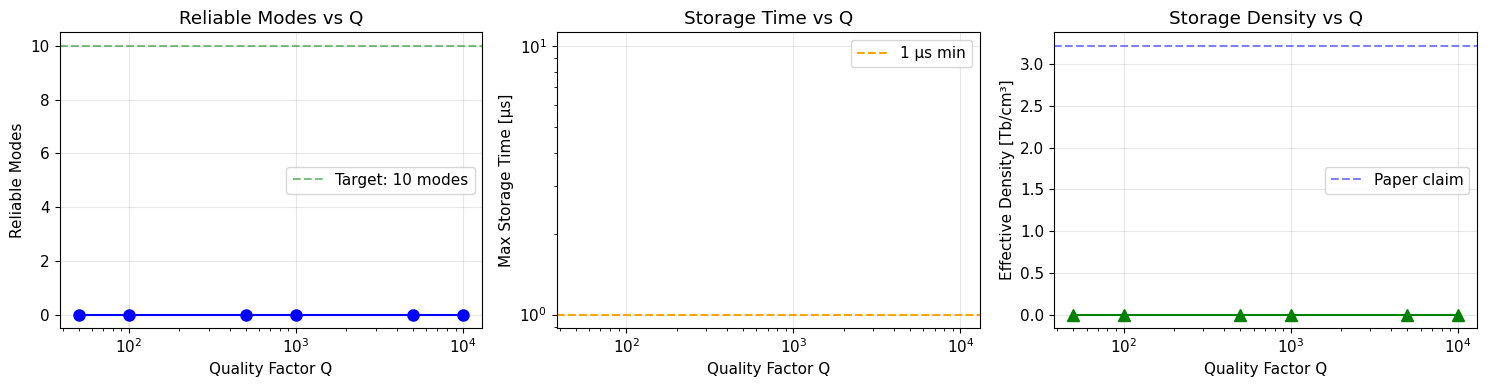

In [9]:
# Q factor sensitivity: the #1 risk parameter
Q_values = [50, 100, 500, 1000, 5000, 10000]
q_results = []
for Q in Q_values:
    p = NoiseParams(Q=Q, n_modes=10, A_signal=1.0)
    r = run_decoherence_analysis(params=p, t_max=1e-3)
    q_results.append(r)
    print(f'Q={Q:>6}: {r.max_reliable_modes} reliable modes, '
          f'storage={r.max_storage_time*1e6:.0f} µs, '
          f'density={r.effective_density_tb_cm3:.2f} Tb/cm³, '
          f'dominant={r.dominant_noise_source}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(Q_values, [r.max_reliable_modes for r in q_results], 'bo-', markersize=8)
axes[0].axhline(y=10, color='g', linestyle='--', alpha=0.5, label='Target: 10 modes')
axes[0].set_xlabel('Quality Factor Q')
axes[0].set_ylabel('Reliable Modes')
axes[0].set_title('Reliable Modes vs Q')
axes[0].legend()

axes[1].loglog(Q_values, [r.max_storage_time*1e6 for r in q_results], 'rs-', markersize=8)
axes[1].axhline(y=1.0, color='orange', linestyle='--', label='1 µs min')
axes[1].set_xlabel('Quality Factor Q')
axes[1].set_ylabel('Max Storage Time [µs]')
axes[1].set_title('Storage Time vs Q')
axes[1].legend()

axes[2].semilogx(Q_values, [r.effective_density_tb_cm3 for r in q_results], 'g^-', markersize=8)
axes[2].axhline(y=3.22, color='b', linestyle='--', alpha=0.5, label='Paper claim')
axes[2].set_xlabel('Quality Factor Q')
axes[2].set_ylabel('Effective Density [Tb/cm³]')
axes[2].set_title('Storage Density vs Q')
axes[2].legend()

plt.tight_layout()
plt.savefig('../analysis/figures/q_factor_sensitivity.png', dpi=150)
plt.show()

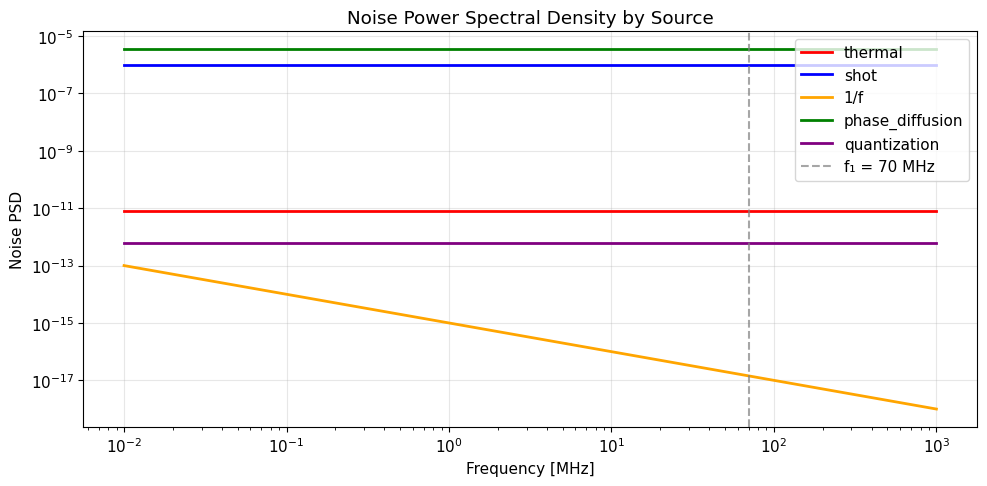

Noise spectrum analysis complete.


In [10]:
# Noise source breakdown across frequency
freqs = np.logspace(4, 9, 200)  # 10 kHz to 1 GHz
noise_sources = {'thermal': [], 'shot': [], '1/f': [],
                 'phase_diffusion': [], 'quantization': []}

p = NoiseParams(Q=500)
for f in freqs:
    ns = compute_noise_spectrum(f, p)
    noise_sources['thermal'].append(ns.thermal)
    noise_sources['shot'].append(ns.shot)
    noise_sources['1/f'].append(ns.one_over_f)
    noise_sources['phase_diffusion'].append(ns.phase_diffusion)
    noise_sources['quantization'].append(ns.quantization)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'thermal': 'red', 'shot': 'blue', '1/f': 'orange',
          'phase_diffusion': 'green', 'quantization': 'purple'}
for name, values in noise_sources.items():
    ax.loglog(freqs / 1e6, values, label=name, color=colors[name], linewidth=2)

# Mark operating frequency
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.7, label='f₁ = 70 MHz')
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Noise PSD')
ax.set_title('Noise Power Spectral Density by Source')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../analysis/figures/noise_spectrum.png', dpi=150)
plt.show()
print('Noise spectrum analysis complete.')

## Part 3: Combined Assessment

In [11]:
# Summary: what do the coupled physics and noise models tell us?
print('=' * 70)
print('  PHASE 2 COMBINED ASSESSMENT')
print('=' * 70)
print()
print('COUPLED MULTIPHYSICS:')
print(f'  Coherence time (5 acoustic + 3 EM modes): {result.coherence_time*1e6:.1f} µs')
print(f'  Energy retained after {result.times[-1]*1e6:.0f} µs: '
      f'{result.total_energy[-1]/result.total_energy[0]*100:.1f}%')
print(f'  Acoustic → EM transfer: negligible (large detuning)')
print(f'  Mode crosstalk: {result.max_mode_crosstalk:.4f}')
print(f'  Thermal heating: {np.max(result.temperature)*1e3:.3f} mK (negligible)')
print()
print('DECOHERENCE (Q=500, 10 modes):')
print(f'  Reliable modes (SNR>10dB): {result_baseline.max_reliable_modes}/10')
print(f'  Max storage time: {result_baseline.max_storage_time*1e6:.1f} µs')
print(f'  Dominant noise: {result_baseline.dominant_noise_source}')
print(f'  Effective density: {result_baseline.effective_density_tb_cm3:.2f} Tb/cm³')
print()
print('KILL CRITERIA CHECK:')
checks = [
    ('Coherence > 1 µs', result.coherence_time > 1e-6),
    ('Energy retained > 50%', result.total_energy[-1]/result.total_energy[0] > 0.5),
    ('Mode crosstalk < 10%', result.max_mode_crosstalk < 0.1),
    ('SNR > 10 dB (all modes)', result_baseline.snr_above_10dB),
    ('BER < 1% (all modes)', result_baseline.ber_below_1pct),
    ('Lifetime > 1 µs', result_baseline.lifetime_above_1us),
    ('Reliable modes ≥ 5', result_baseline.max_reliable_modes >= 5),
]
for name, passed in checks:
    status = '✅ PASS' if passed else '❌ FAIL'
    print(f'  {status}  {name}')

n_pass = sum(1 for _, p in checks if p)
n_fail = len(checks) - n_pass
print(f'\n  Result: {n_pass} PASS / {n_fail} FAIL')
if n_fail == 0:
    print('  → Architecture viable under these conditions')
elif n_fail <= 2:
    print('  → Marginal — needs parameter optimization')
else:
    print('  → Significant concerns — review assumptions')
print('=' * 70)

  PHASE 2 COMBINED ASSESSMENT

COUPLED MULTIPHYSICS:
  Coherence time (5 acoustic + 3 EM modes): 500.0 µs
  Energy retained after 500 µs: 95.1%
  Acoustic → EM transfer: negligible (large detuning)
  Mode crosstalk: 1.0000
  Thermal heating: 0.010 mK (negligible)

DECOHERENCE (Q=500, 10 modes):
  Reliable modes (SNR>10dB): 0/10
  Max storage time: 0.0 µs
  Dominant noise: phase_diffusion
  Effective density: 0.00 Tb/cm³

KILL CRITERIA CHECK:
  ✅ PASS  Coherence > 1 µs
  ✅ PASS  Energy retained > 50%
  ❌ FAIL  Mode crosstalk < 10%
  ❌ FAIL  SNR > 10 dB (all modes)
  ❌ FAIL  BER < 1% (all modes)
  ❌ FAIL  Lifetime > 1 µs
  ❌ FAIL  Reliable modes ≥ 5

  Result: 2 PASS / 5 FAIL
  → Significant concerns — review assumptions
